# MotorNet-JAX: Building Effectors

This notebook demonstrates how to build and use effectors (muscle-skeleton systems) in MotorNet-JAX.

An **effector** combines:
- A **skeleton** (defines the mechanical system - bones, joints)
- **Muscles** (produce forces based on activation)
- **Geometry** (how muscles wrap around the skeleton)

In [1]:
import os
import sys

# Add parent directory to path for imports
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath('.')))))

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from functools import partial

import motornet_jax as mn
from motornet_jax.types import JointState
from motornet_jax.skeleton import TwoDofArm, PointMass
from motornet_jax.effector import Arm26

print('All packages imported.')
print(f'JAX version: {jax.__version__}')
print(f'MotorNet-JAX version: {mn.__version__}')

All packages imported.
JAX version: 0.9.0
MotorNet-JAX version: 0.1.0


## I. The TwoDofArm Skeleton

The `TwoDofArm` is a planar two-link arm with shoulder and elbow joints. It's the foundation for arm reaching models.

### Key Parameters:
- `m1, m2`: Segment masses (kg)
- `l1, l2`: Segment lengths (m)
- `l1g, l2g`: Distance to center of mass (m)
- `i1, i2`: Moments of inertia (kg⋅m²)

In [2]:
# Create a TwoDofArm skeleton
skeleton = TwoDofArm(
    m1=1.82, m2=1.43,      # Segment masses
    l1=0.309, l2=0.333,    # Segment lengths
    l1g=0.135, l2g=0.165,  # Distance to COM
    i1=0.051, i2=0.057,    # Moments of inertia
)
params = skeleton.get_params()

print("TwoDofArm Parameters:")
print(f"  Segment 1: mass={params.M1}kg, length={params.L1}m")
print(f"  Segment 2: mass={params.M2}kg, length={params.L2}m")
print(f"  Total arm length: {params.L1 + params.L2}m")
print(f"\n  Joint limits:")
print(f"    Shoulder: {np.rad2deg(params.pos_lower_bound[0]):.0f}° to {np.rad2deg(params.pos_upper_bound[0]):.0f}°")
print(f"    Elbow: {np.rad2deg(params.pos_lower_bound[1]):.0f}° to {np.rad2deg(params.pos_upper_bound[1]):.0f}°")

TwoDofArm Parameters:
  Segment 1: mass=1.82kg, length=0.309m
  Segment 2: mass=1.43kg, length=0.333m
  Total arm length: 0.642m

  Joint limits:
    Shoulder: 0° to 140°
    Elbow: 0° to 160°


## II. Forward Kinematics

Forward kinematics converts joint angles to Cartesian (x, y) positions.

In [3]:
# Create a grid of joint angles
n_points = 21
shoulder_angles = jnp.linspace(params.pos_lower_bound[0], params.pos_upper_bound[0], n_points)
elbow_angles = jnp.linspace(params.pos_lower_bound[1], params.pos_upper_bound[1], n_points)

sho_grid, elb_grid = jnp.meshgrid(shoulder_angles, elbow_angles)

# Flatten for batched computation
joint_positions = jnp.stack([sho_grid.flatten(), elb_grid.flatten()], axis=1)

# Create joint state
joint_state = JointState(
    position=joint_positions,
    velocity=jnp.zeros_like(joint_positions),
)

# Compute forward kinematics
elbow_pos, hand_pos, elbow_vel, hand_vel = TwoDofArm.forward_kinematics(joint_state, params)

print(f"Computed {len(hand_pos)} hand positions")
print(f"Workspace bounds: x=[{hand_pos[:, 0].min():.3f}, {hand_pos[:, 0].max():.3f}], "
      f"y=[{hand_pos[:, 1].min():.3f}, {hand_pos[:, 1].max():.3f}]")

Computed 441 hand positions
Workspace bounds: x=[-0.570, 0.642], y=[-0.134, 0.642]


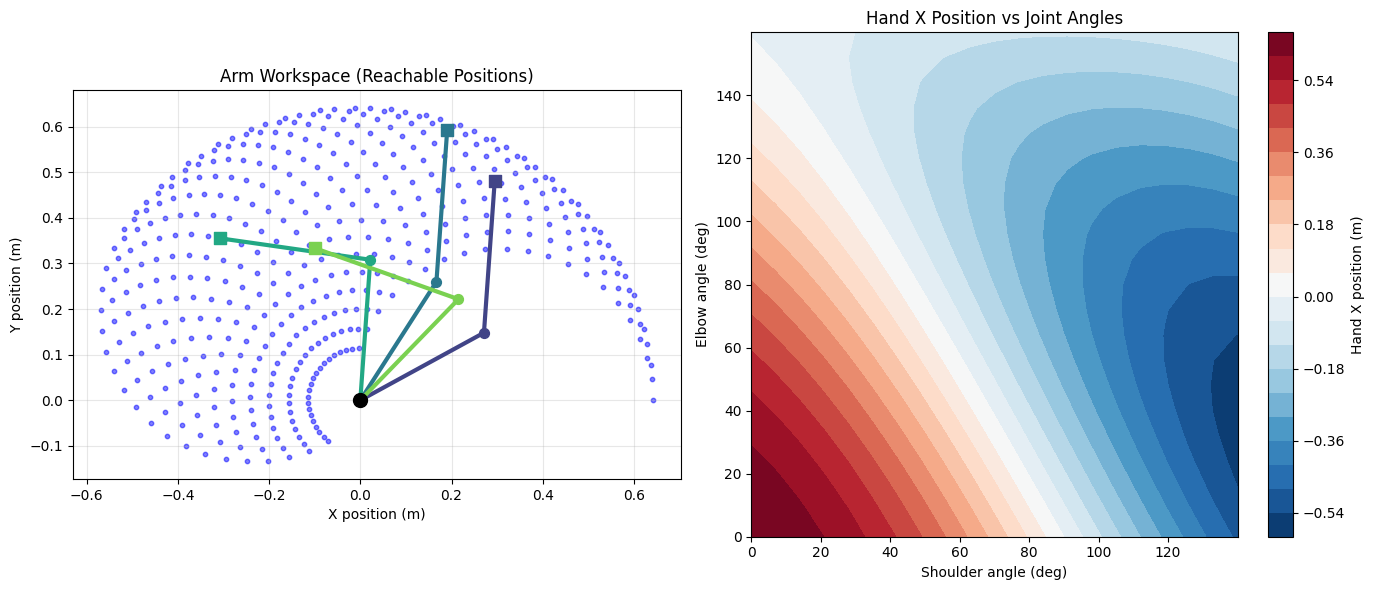

In [4]:
# Visualize the workspace
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot workspace (hand positions)
ax = axes[0]
ax.scatter(hand_pos[:, 0], hand_pos[:, 1], c='blue', alpha=0.5, s=10)
ax.set_xlabel('X position (m)')
ax.set_ylabel('Y position (m)')
ax.set_title('Arm Workspace (Reachable Positions)')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# Draw some arm configurations
ax.scatter([0], [0], c='black', s=100, marker='o', zorder=5, label='Shoulder')

# Sample configurations
sample_angles = [
    (0.5, 1.0),
    (1.0, 0.5),
    (1.5, 1.5),
    (0.8, 2.0),
]

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(sample_angles)))
for (sho, elb), color in zip(sample_angles, colors):
    state = JointState(
        position=jnp.array([[sho, elb]]),
        velocity=jnp.zeros((1, 2)),
    )
    elbow, hand, _, _ = TwoDofArm.forward_kinematics(state, params)
    
    # Draw arm
    ax.plot([0, elbow[0, 0]], [0, elbow[0, 1]], c=color, linewidth=3)
    ax.plot([elbow[0, 0], hand[0, 0]], [elbow[0, 1], hand[0, 1]], c=color, linewidth=3)
    ax.scatter([elbow[0, 0]], [elbow[0, 1]], c=[color], s=50, zorder=5)
    ax.scatter([hand[0, 0]], [hand[0, 1]], c=[color], s=80, marker='s', zorder=5)

# Plot joint angle to Cartesian mapping
ax = axes[1]
hand_x = hand_pos[:, 0].reshape(n_points, n_points)
hand_y = hand_pos[:, 1].reshape(n_points, n_points)

# Contour plot of X position as function of joint angles
contour = ax.contourf(np.rad2deg(sho_grid), np.rad2deg(elb_grid), hand_x, levels=20, cmap='RdBu_r')
plt.colorbar(contour, ax=ax, label='Hand X position (m)')
ax.set_xlabel('Shoulder angle (deg)')
ax.set_ylabel('Elbow angle (deg)')
ax.set_title('Hand X Position vs Joint Angles')

plt.tight_layout()
plt.show()

## III. The Arm26 Effector

The `Arm26` combines the TwoDofArm skeleton with 6 muscles using polynomial moment arm approximation.

### Muscles:
1. **Pectoralis** - Shoulder flexor
2. **Deltoid** - Shoulder extensor
3. **Brachioradialis** - Elbow flexor
4. **Triceps Lateral** - Elbow extensor
5. **Biceps** - Biarticular flexor (crosses both joints)
6. **Triceps Long** - Biarticular extensor (crosses both joints)

In [5]:
# Create Arm26 effector
arm = Arm26(dt=0.01, n_ministeps=1)
arm_params = arm.get_params()

print("Arm26 Effector:")
print(f"  Number of muscles: {arm.n_muscles}")
print(f"  Number of joints: {arm.n_joints}")
print(f"\nMuscle Properties:")
for i, name in enumerate(arm.muscle_names):
    print(f"  {name}:")
    print(f"    Max isometric force: {arm_params.max_isometric_force[i]:.0f} N")
    print(f"    Optimal fiber length: {arm_params.optimal_fiber_length[i]*100:.1f} cm")
    print(f"    Tendon slack length: {arm_params.tendon_slack_length[i]*100:.1f} cm")

Arm26 Effector:
  Number of muscles: 6
  Number of joints: 2

Muscle Properties:
  pectoralis:
    Max isometric force: 838 N
    Optimal fiber length: 13.4 cm
    Tendon slack length: 3.9 cm
  deltoid:
    Max isometric force: 1207 N
    Optimal fiber length: 14.0 cm
    Tendon slack length: 6.6 cm
  brachioradialis:
    Max isometric force: 1422 N
    Optimal fiber length: 9.2 cm
    Tendon slack length: 17.2 cm
  tricepslat:
    Max isometric force: 1549 N
    Optimal fiber length: 9.3 cm
    Tendon slack length: 18.7 cm
  biceps:
    Max isometric force: 414 N
    Optimal fiber length: 13.7 cm
    Tendon slack length: 20.4 cm
  tricepslong:
    Max isometric force: 603 N
    Optimal fiber length: 12.7 cm
    Tendon slack length: 21.7 cm


## IV. Moment Arms

**Moment arms** describe how effectively each muscle can change each joint angle. They depend on:
- Muscle geometry (path around joints)
- Current joint configuration

In Arm26, moment arms are computed using polynomial approximation:
$$\text{moment arm} = a_1 + 2 \cdot a_2 \cdot (\theta - \theta_0)$$

In [6]:
# Compute geometry across joint space
joint_state = JointState(
    position=joint_positions,
    velocity=jnp.zeros_like(joint_positions),
)

geometry = Arm26.compute_geometry(joint_state, arm_params)

print(f"Geometry shapes:")
print(f"  Musculotendon length: {geometry.musculotendon_length.shape}")
print(f"  Moment arm: {geometry.moment_arm.shape}")

Geometry shapes:
  Musculotendon length: (441, 6)
  Moment arm: (441, 6, 2)


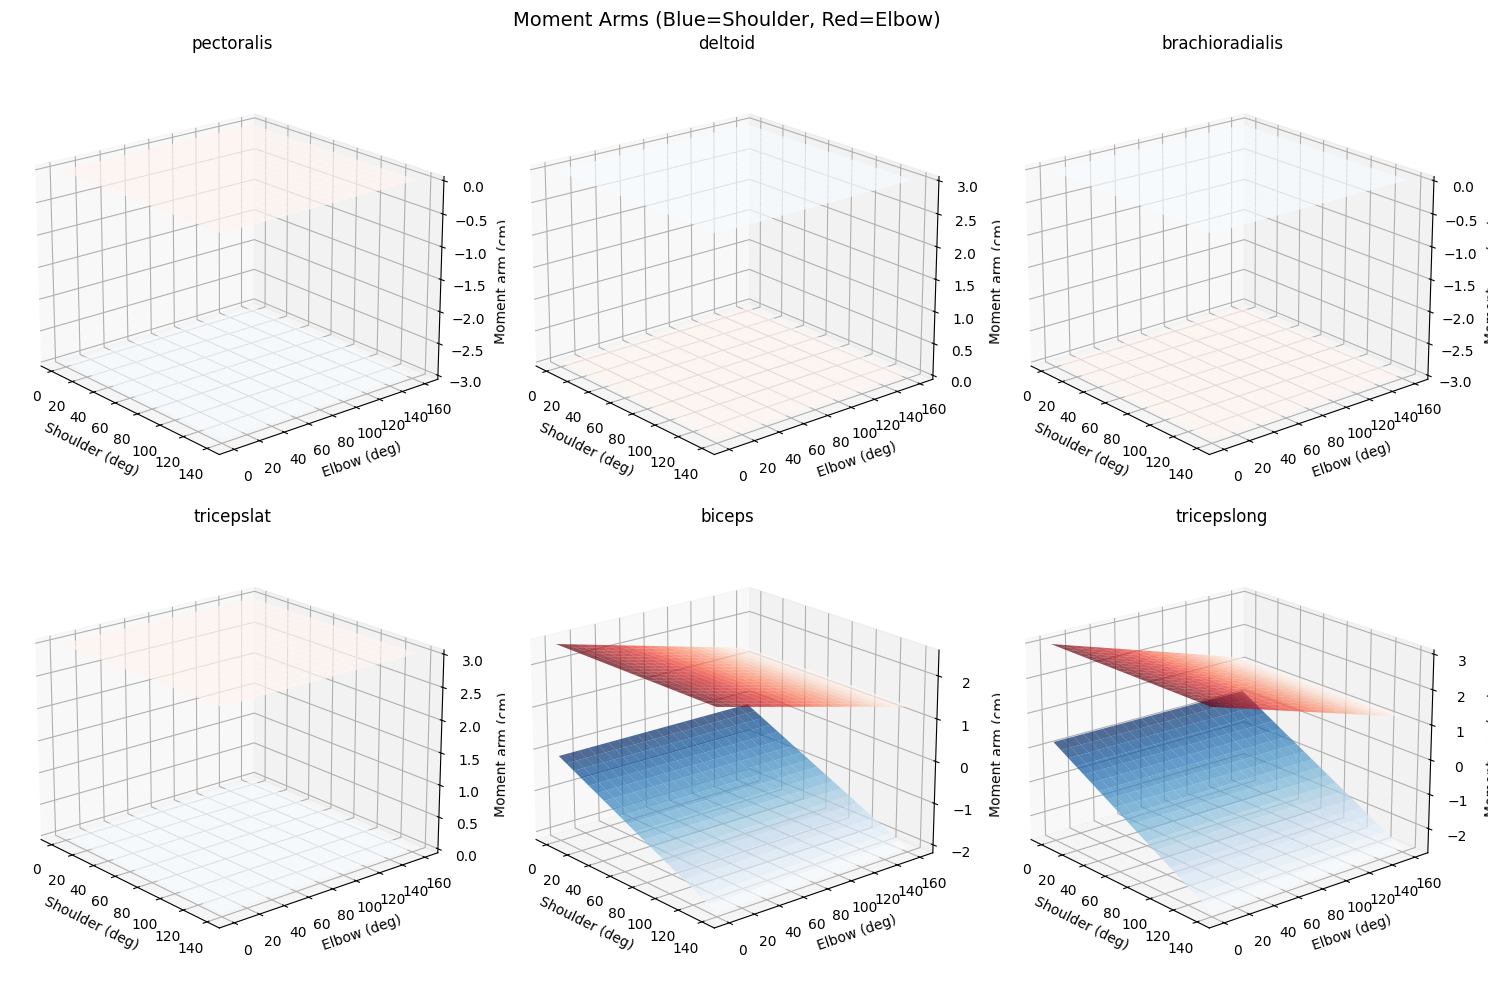

In [7]:
# Plot moment arms for each muscle
fig = plt.figure(figsize=(15, 10))

for m in range(arm.n_muscles):
    ax = fig.add_subplot(2, 3, m+1, projection='3d')
    
    # Moment arm for shoulder (index 0) and elbow (index 1)
    ma_shoulder = geometry.moment_arm[:, m, 0].reshape(n_points, n_points) * 100  # to cm
    ma_elbow = geometry.moment_arm[:, m, 1].reshape(n_points, n_points) * 100
    
    # Plot both surfaces
    ax.plot_surface(np.rad2deg(sho_grid), np.rad2deg(elb_grid), ma_shoulder, 
                    cmap='Blues', alpha=0.7, label='Shoulder')
    ax.plot_surface(np.rad2deg(sho_grid), np.rad2deg(elb_grid), ma_elbow, 
                    cmap='Reds', alpha=0.7, label='Elbow')
    
    ax.set_xlabel('Shoulder (deg)')
    ax.set_ylabel('Elbow (deg)')
    ax.set_zlabel('Moment arm (cm)')
    ax.set_title(arm.muscle_names[m])
    ax.view_init(20, -40)

plt.suptitle('Moment Arms (Blue=Shoulder, Red=Elbow)', fontsize=14)
plt.tight_layout()
plt.show()

### Interpretation:

- **Pectoralis & Deltoid**: Only affect shoulder (flat red surface at 0)
- **Brachioradialis & Triceps Lat**: Only affect elbow (flat blue surface at 0)
- **Biceps & Triceps Long**: Biarticular - affect both joints (both surfaces non-zero)

## V. Muscle Lengths

Muscle length depends on joint angles. For the polynomial approximation:
$$L = a_0 + \sum_j (a_1^j + a_2^j \cdot \theta_j) \cdot \theta_j$$

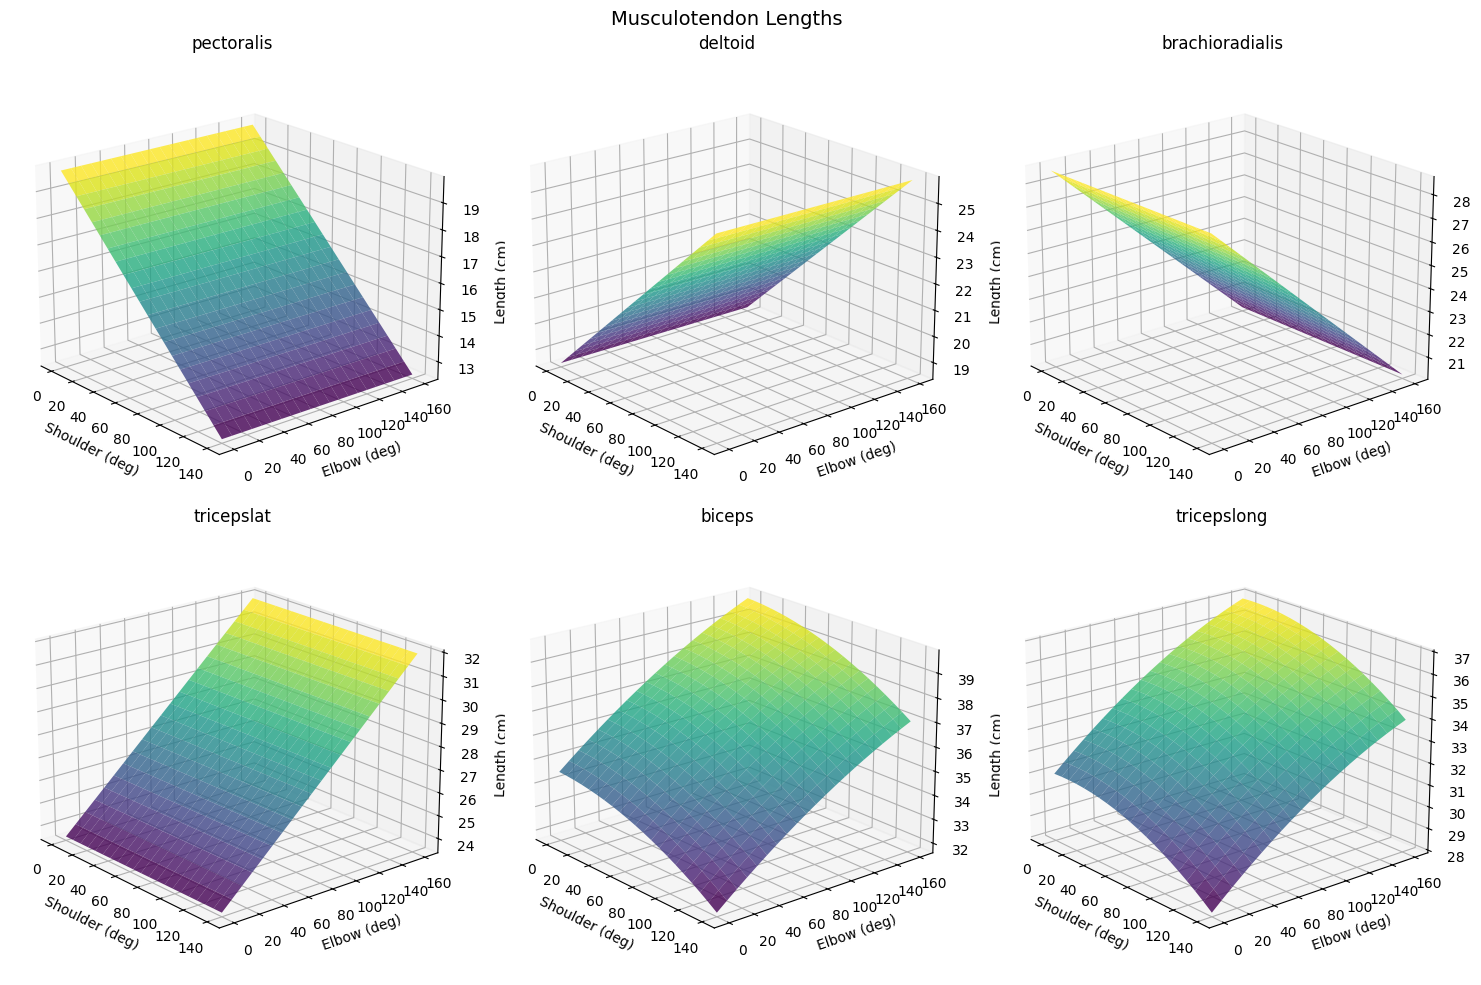

In [8]:
# Plot muscle lengths
fig = plt.figure(figsize=(15, 10))

for m in range(arm.n_muscles):
    ax = fig.add_subplot(2, 3, m+1, projection='3d')
    
    muscle_length = geometry.musculotendon_length[:, m].reshape(n_points, n_points) * 100  # to cm
    
    surf = ax.plot_surface(np.rad2deg(sho_grid), np.rad2deg(elb_grid), muscle_length, 
                           cmap='viridis', alpha=0.8)
    
    ax.set_xlabel('Shoulder (deg)')
    ax.set_ylabel('Elbow (deg)')
    ax.set_zlabel('Length (cm)')
    ax.set_title(arm.muscle_names[m])
    ax.view_init(20, -40)

plt.suptitle('Musculotendon Lengths', fontsize=14)
plt.tight_layout()
plt.show()

## VI. Simulating Movement

Now let's simulate the arm under different muscle activations.

In [9]:
# Simulation function
@partial(jax.jit, static_argnums=(4,))
def simulate(state, action, endpoint_load, joint_load, n_steps):
    def step_fn(state, _):
        new_state = Arm26.step(state, action, endpoint_load, joint_load, arm_params)
        return new_state, new_state.fingertip[0]
    
    final_state, trajectory = jax.lax.scan(step_fn, state, None, length=n_steps)
    return final_state, trajectory

# Initial position (mid-range)
initial_joint = JointState(
    position=jnp.array([[1.0, 1.2]]),
    velocity=jnp.zeros((1, 2)),
)

n_steps = 200
endpoint_load = jnp.zeros((1, 2))
joint_load = jnp.zeros((1, 2))

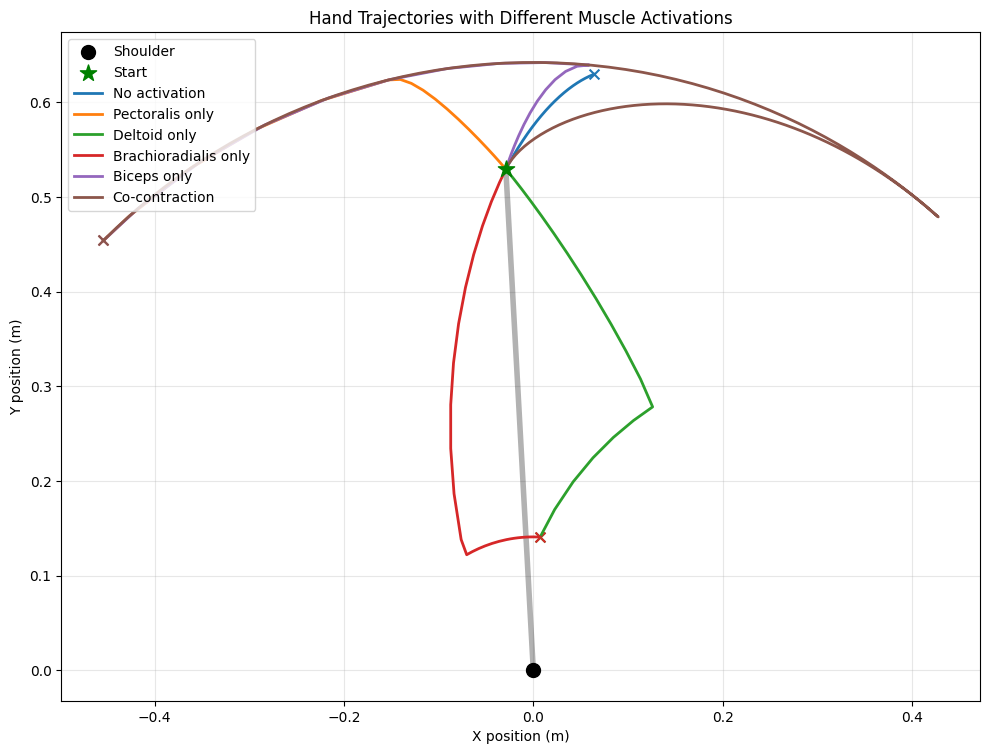

In [10]:
# Simulate with different activation patterns
patterns = {
    'No activation': jnp.zeros((1, 6)),
    'Pectoralis only': jnp.array([[1.0, 0, 0, 0, 0, 0]]),
    'Deltoid only': jnp.array([[0, 1.0, 0, 0, 0, 0]]),
    'Brachioradialis only': jnp.array([[0, 0, 1.0, 0, 0, 0]]),
    'Biceps only': jnp.array([[0, 0, 0, 0, 1.0, 0]]),
    'Co-contraction': jnp.array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5]]),
}

trajectories = {}
for name, action in patterns.items():
    state = arm.reset(batch_size=1, joint_state=initial_joint)
    final, traj = simulate(state, action, endpoint_load, joint_load, n_steps)
    trajectories[name] = traj

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

# Draw arm at initial position
state = arm.reset(batch_size=1, joint_state=initial_joint)
ax.scatter([0], [0], c='black', s=100, marker='o', zorder=10, label='Shoulder')
ax.plot([0, state.cartesian.position[0, 0]], [0, state.cartesian.position[0, 1]], 
        'k-', linewidth=4, alpha=0.3)
ax.scatter([state.fingertip[0, 0]], [state.fingertip[0, 1]], 
           c='green', s=150, marker='*', zorder=10, label='Start')

# Plot trajectories
for name, traj in trajectories.items():
    ax.plot(traj[:, 0], traj[:, 1], linewidth=2, label=name)
    ax.scatter([traj[-1, 0]], [traj[-1, 1]], s=50, marker='x')

ax.set_xlabel('X position (m)')
ax.set_ylabel('Y position (m)')
ax.set_title('Hand Trajectories with Different Muscle Activations')
ax.legend(loc='upper left')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## VII. Passive Drift

Hill-type muscles produce passive forces when stretched beyond their slack length. This causes the arm to drift toward equilibrium positions at the edge of the workspace.

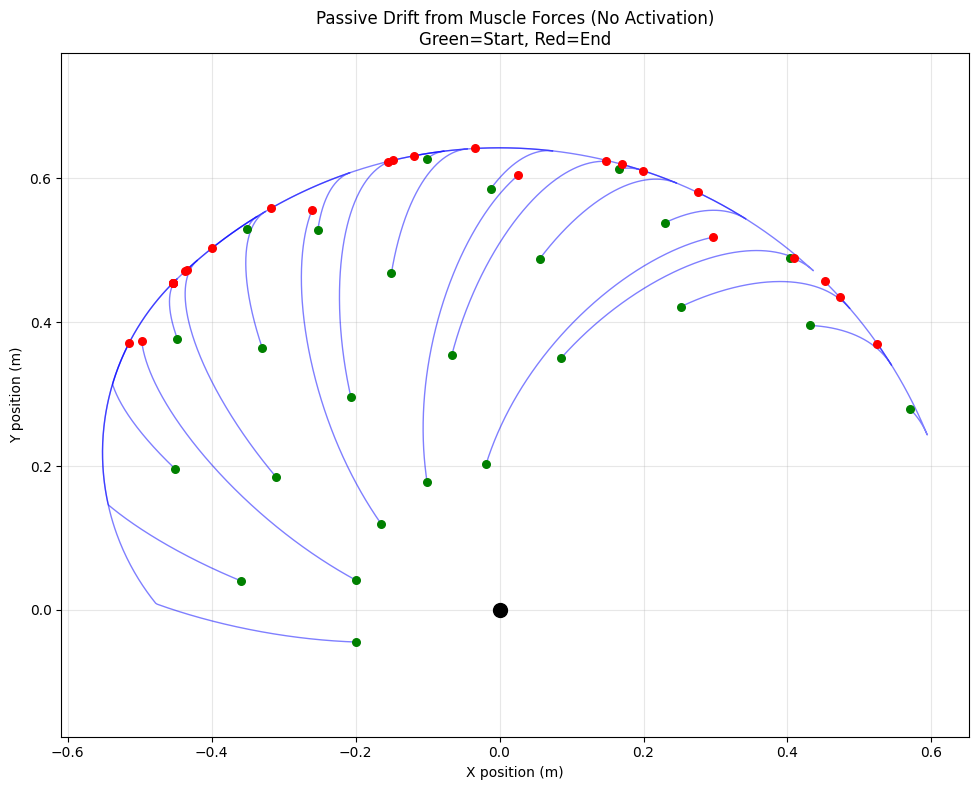

In [11]:
# Simulate passive drift from multiple starting positions
n_starts = 25
n_steps = 300

# Grid of starting positions
sho_starts = jnp.linspace(0.3, 2.0, 5)
elb_starts = jnp.linspace(0.3, 2.5, 5)
sho_grid_s, elb_grid_s = jnp.meshgrid(sho_starts, elb_starts)
start_positions = jnp.stack([sho_grid_s.flatten(), elb_grid_s.flatten()], axis=1)

# No muscle activation
action = jnp.zeros((n_starts, 6))
endpoint_load = jnp.zeros((n_starts, 2))
joint_load = jnp.zeros((n_starts, 2))

# Simulate
@jax.jit
def simulate_batch(start_positions):
    state = arm.reset(
        batch_size=n_starts,
        joint_state=JointState(
            position=start_positions,
            velocity=jnp.zeros((n_starts, 2)),
        )
    )
    
    def step_fn(state, _):
        new_state = Arm26.step(state, action, endpoint_load, joint_load, arm_params)
        return new_state, new_state.fingertip
    
    final, trajectories = jax.lax.scan(step_fn, state, None, length=n_steps)
    return trajectories

trajectories = simulate_batch(start_positions)

# Plot
plt.figure(figsize=(10, 8))

for i in range(n_starts):
    traj = trajectories[:, i, :]
    plt.plot(traj[:, 0], traj[:, 1], 'b-', alpha=0.5, linewidth=1)
    plt.scatter([traj[0, 0]], [traj[0, 1]], c='green', s=30, zorder=5)
    plt.scatter([traj[-1, 0]], [traj[-1, 1]], c='red', s=30, zorder=5)

plt.scatter([0], [0], c='black', s=100, marker='o', zorder=10, label='Shoulder')
plt.xlabel('X position (m)')
plt.ylabel('Y position (m)')
plt.title('Passive Drift from Muscle Forces (No Activation)\nGreen=Start, Red=End')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## VIII. JAX Performance Features

MotorNet-JAX is designed for high performance through:
1. **JIT Compilation**: Functions are compiled to optimized machine code
2. **Vectorization (vmap)**: Automatic parallelization over batches
3. **Efficient Loops (lax.scan)**: No Python overhead for time loops

Batch size    1:    1,161,659 steps/sec
Batch size    8:    9,750,449 steps/sec
Batch size   64:   14,136,331 steps/sec
Batch size  256:   15,398,643 steps/sec
Batch size 1024:   10,724,829 steps/sec


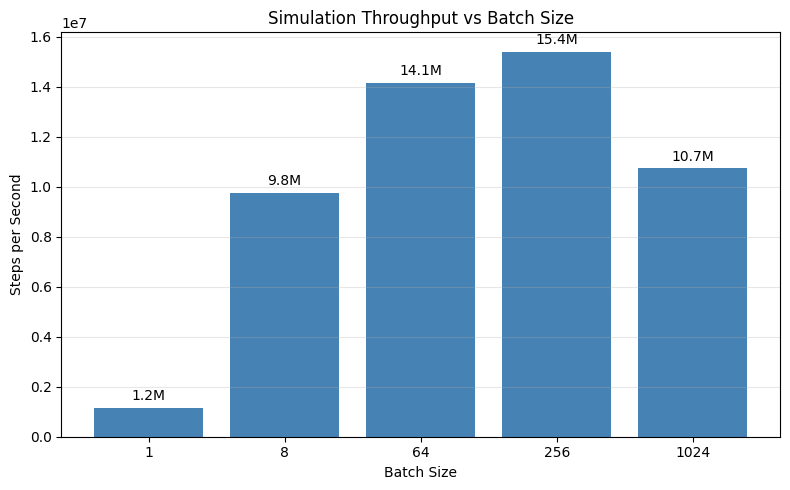

In [12]:
import time

# Benchmark different batch sizes
batch_sizes = [1, 8, 64, 256, 1024]
n_steps = 100
n_trials = 100

results = []

for batch_size in batch_sizes:
    key = jax.random.PRNGKey(0)
    action = jnp.ones((batch_size, 6)) * 0.3
    endpoint_load = jnp.zeros((batch_size, 2))
    joint_load = jnp.zeros((batch_size, 2))
    
    @jax.jit
    def run_episode(key):
        state = arm.reset(batch_size=batch_size, key=key)
        
        def step_fn(state, _):
            new_state = Arm26.step(state, action, endpoint_load, joint_load, arm_params)
            return new_state, None
        
        final, _ = jax.lax.scan(step_fn, state, None, length=n_steps)
        return final
    
    # Warmup
    _ = run_episode(key)
    _.joint.position.block_until_ready()
    
    # Benchmark
    start = time.perf_counter()
    for i in range(n_trials):
        key = jax.random.PRNGKey(i)
        final = run_episode(key)
    final.joint.position.block_until_ready()
    elapsed = time.perf_counter() - start
    
    total_steps = n_trials * n_steps * batch_size
    steps_per_sec = total_steps / elapsed
    
    results.append({
        'batch_size': batch_size,
        'steps_per_sec': steps_per_sec,
    })
    print(f"Batch size {batch_size:4d}: {steps_per_sec:>12,.0f} steps/sec")

# Plot
plt.figure(figsize=(8, 5))
batch_sizes_arr = [r['batch_size'] for r in results]
steps_arr = [r['steps_per_sec'] for r in results]

plt.bar(range(len(batch_sizes_arr)), steps_arr, color='steelblue')
plt.xticks(range(len(batch_sizes_arr)), batch_sizes_arr)
plt.xlabel('Batch Size')
plt.ylabel('Steps per Second')
plt.title('Simulation Throughput vs Batch Size')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(steps_arr):
    plt.text(i, v + max(steps_arr)*0.02, f'{v/1e6:.1f}M', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Summary

In this notebook we covered:

1. **TwoDofArm Skeleton**: 2-DOF planar arm with forward kinematics
2. **Arm26 Effector**: 6-muscle arm with polynomial geometry
3. **Moment Arms**: How muscles affect joint angles
4. **Muscle Lengths**: Musculotendon length vs joint angles
5. **Movement Simulation**: Arm dynamics under muscle activation
6. **Passive Drift**: Equilibrium from passive muscle forces
7. **JAX Performance**: Millions of steps per second with batching

### Key Differences from PyTorch MotorNet:

| Feature | PyTorch MotorNet | MotorNet-JAX |
|---------|------------------|---------------|
| State storage | In object | Explicit (passed to functions) |
| Geometry | Path-based | Polynomial approximation |
| Compilation | Eager execution | XLA JIT compilation |
| Batching | Manual loops | Automatic with vmap |
| Gradients | torch.autograd | jax.grad |